# 51 Regresión Lineal — Comparativa OLS Base vs Ridge vs Lasso+OLS

Unificación de los tres notebooks de regresión lineal para `sale` y `rent` prediciendo `log_precio`.

| Modelo | Features | Regularización | Inferencia |
|--------|----------|---------------|------------|
| **OLS Base** | 11 features parsimoniosas | Ninguna | statsmodels (coef, p-value, IC95) |
| **Ridge** | Conjunto completo + municipios | L2 (RidgeCV) | coef estandarizados |
| **Lasso+OLS** | Conjunto completo + municipios → selección Lasso | L1 (LassoCV) + OLS | statsmodels (coef, p-value, IC95) |

**Pipeline común:**
1. Eliminación de outliers en `log_precio` con método IQR antes del split
2. Split 80/20 train/test (`random_state=42`)
3. Validación cruzada 5-fold (CV=5): MSE, RMSE, MAE, MAPE y R²
4. Gráficos diagnósticos: Real vs Predicho, residuos, histograma residuos
5. **Resumen comparativo global** al final

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression, LassoCV, Ridge, RidgeCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

In [2]:
# ── Configuración global ──────────────────────────────────────────────────────
RANDOM_STATE            = 42
TEST_SIZE               = 0.20
N_SPLITS                = 5
TARGET_COL              = "log_precio"
IQR_FACTOR              = 1.5
MIN_MUNICIPIO_REGISTROS = 10

# Alphas candidatos para RidgeCV
RIDGE_ALPHAS = np.logspace(-3, 5, 200)

# ── Features OLS Base (parsimonioso — 11 regresores) ─────────────────────────
BASE_FEATURES = [
    "log_superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "distancia_centro_municipio_km",
    "tipologia_unificada_unifamiliar",
    "precio_m2_municipio_media",
]

# ── Features candidatas Ridge (20 regresores) ────────────────────────────────
# es_exterior / tiene_ascensor → renombradas a *_piso en build_candidate_X
CANDIDATE_FEATURES_RIDGE = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "latitud",
    "longitud",
    "planta",
    "es_exterior",                    # → renombrado a es_exterior_piso
    "tiene_ascensor",                 # → renombrado a tiene_ascensor_piso
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "precio_m2_municipio_media",
    "ratio_dormitorios_superficie",
    "ratio_banos_superficie",
    "interaccion_planta_sin_ascensor_piso",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    # municipio_* se añaden dinámicamente
]

# ── Features candidatas Lasso (28 regresores) ────────────────────────────────
# es_exterior / tiene_ascensor → renombradas a *_piso en build_candidate_X
CANDIDATE_FEATURES_LASSO = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "latitud",
    "longitud",
    "planta",
    "es_exterior",                    # → renombrado a es_exterior_piso
    "tiene_ascensor",                 # → renombrado a tiene_ascensor_piso
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "precio_m2_municipio_media",
    "ratio_banos_superficie",
    "interaccion_superficie_banos",
    "planta_num",
    "interaccion_planta_sin_ascensor_piso",
    "latitud_2",
    "longitud_2",
    "interaccion_latitud_longitud",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "superficie_construida_m2_2",
    "numero_banos_2",
    "numero_dormitorios_2",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # municipio_* se añaden dinámicamente
]

# ── Rutas de datos ────────────────────────────────────────────────────────────
def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data" / "gold").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto con data/gold")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent.csv",
}

for name, path in DATASETS.items():
    if not path.exists():
        raise FileNotFoundError(f"No se encontro {name}: {path}")

print("Datasets listos:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets listos:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent.csv


In [3]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def remove_outliers_iqr(df: pd.DataFrame, col: str = TARGET_COL) -> pd.DataFrame:
    """Elimina outliers en `col` con método IQR antes del split."""
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr     = q3 - q1
    lower   = q1 - IQR_FACTOR * iqr
    upper   = q3 + IQR_FACTOR * iqr
    mask    = df[col].between(lower, upper)
    n_out   = (~mask).sum()
    print(f"  Rango valido [{col}]: [{lower:.4f}, {upper:.4f}]")
    print(f"  Outliers eliminados: {n_out} / {len(df)} ({n_out / len(df) * 100:.1f}%)")
    return df[mask].copy()


def compute_metrics(y_true, y_pred, n_features: int) -> dict:
    mse    = mean_squared_error(y_true, y_pred)
    r2     = r2_score(y_true, y_pred)
    n      = len(y_true)
    r2_adj = (
        1 - (1 - r2) * (n - 1) / (n - n_features - 1)
        if n > n_features + 1 else np.nan
    )
    return {
        "MSE":         float(mse),
        "RMSE":        float(np.sqrt(mse)),
        "MAE":         float(mean_absolute_error(y_true, y_pred)),
        "MAPE":        float(mean_absolute_percentage_error(y_true, y_pred)),
        "R2":          float(r2),
        "R2_ajustado": float(r2_adj),
    }


def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    """VIF para cada regresor. VIF > 5 → moderada; VIF > 10 → severa."""
    Xc  = sm.add_constant(X.astype(float))
    vif = pd.DataFrame({
        "feature": Xc.columns,
        "VIF":     [variance_inflation_factor(Xc.values.astype(float), i)
                    for i in range(Xc.shape[1])],
    })
    return (
        vif[vif["feature"] != "const"]
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )


def cv_ols_metrics(X: pd.DataFrame, y: pd.Series, n_features: int) -> dict:
    """Validacion cruzada 5-fold con LinearRegression (equiv. OLS)."""
    kf           = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_results = []
    for tr_idx, val_idx in kf.split(X):
        mdl = LinearRegression()
        mdl.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = mdl.predict(X.iloc[val_idx])
        fold_results.append(compute_metrics(y.iloc[val_idx], pred, n_features))
    return {k: float(np.mean([m[k] for m in fold_results])) for k in fold_results[0]}


def cv_ridge_metrics(X: pd.DataFrame, y: pd.Series, alpha: float, n_features: int) -> dict:
    """Validacion cruzada 5-fold con Ridge (estandarizado dentro de cada fold)."""
    kf           = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_results = []
    for tr_idx, val_idx in kf.split(X):
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge",  Ridge(alpha=alpha)),
        ])
        pipe.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = pipe.predict(X.iloc[val_idx])
        fold_results.append(compute_metrics(y.iloc[val_idx], pred, n_features))
    return {k: float(np.mean([m[k] for m in fold_results])) for k in fold_results[0]}


def fit_ols_statsmodels(X_train: pd.DataFrame, y_train: pd.Series):
    """Ajusta OLS con statsmodels (incluye constante)."""
    Xc = sm.add_constant(X_train.astype(float))
    return sm.OLS(y_train, Xc).fit()


def print_coef_summary(result) -> None:
    """Tabla de coeficientes OLS ordenada por magnitud absoluta."""
    coef_df = pd.DataFrame({
        "coef":      result.params,
        "std_err":   result.bse,
        "t":         result.tvalues,
        "p_value":   result.pvalues,
        "IC_95_inf": result.conf_int()[0],
        "IC_95_sup": result.conf_int()[1],
    })
    coef_df = coef_df.drop(index="const", errors="ignore")
    coef_df["|coef|"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("|coef|", ascending=False).drop(columns="|coef|")
    print(coef_df.round(5).to_string())


def group_small_municipios(df: pd.DataFrame) -> tuple:
    """Agrupa municipio_* con < MIN_MUNICIPIO_REGISTROS en 'municipio_otros'."""
    mun_cols   = [c for c in df.columns if c.startswith("municipio_")]
    if not mun_cols:
        return df, []
    mun_counts = df[mun_cols].sum()
    small_muns = mun_counts[mun_counts < MIN_MUNICIPIO_REGISTROS].index.tolist()
    big_muns   = mun_counts[mun_counts >= MIN_MUNICIPIO_REGISTROS].index.tolist()
    print(f"  Municipios agrupados en 'otros' (n={len(small_muns)}): "
          f"{sorted([m.replace('municipio_','') for m in small_muns])}")
    print(f"  Municipios mantenidos (n={len(big_muns)}): "
          f"{sorted([m.replace('municipio_','') for m in big_muns])}")
    df = df.copy()
    if small_muns:
        df["municipio_otros"] = df[small_muns].max(axis=1)
        df = df.drop(columns=small_muns)
    final_mun_cols = sorted([c for c in df.columns if c.startswith("municipio_")])
    return df, final_mun_cols


def build_base_X(df: pd.DataFrame) -> pd.DataFrame:
    """Matriz de features parsimoniosa para OLS base."""
    features = [f for f in BASE_FEATURES if f in df.columns]
    X = df[features].copy()
    return X.fillna(X.median(numeric_only=True))


def build_candidate_X(df: pd.DataFrame, candidate_features: list) -> pd.DataFrame:
    """Matriz de features para Ridge o Lasso (con municipios)."""
    df2, mun_cols = group_small_municipios(df)
    rename_map = {}
    if "es_exterior" in df2.columns:
        df2["es_exterior_piso"]  = df2["es_exterior"]
        rename_map["es_exterior"] = "es_exterior_piso"
    if "tiene_ascensor" in df2.columns:
        df2["tiene_ascensor_piso"]  = df2["tiene_ascensor"]
        rename_map["tiene_ascensor"] = "tiene_ascensor_piso"
    base_feats = []
    for f in candidate_features:
        mapped = rename_map.get(f, f)
        if mapped in df2.columns and mapped not in base_feats:
            base_feats.append(mapped)
    all_feats = base_feats + [m for m in mun_cols if m not in base_feats]
    all_feats = [f for f in all_feats if f in df2.columns]
    X = df2[all_feats].copy()
    return X.fillna(X.median(numeric_only=True))


def select_features_lasso(X_train: pd.DataFrame, y_train: pd.Series) -> tuple:
    """Usa LassoCV (estandarizado, CV=5) para seleccionar features con coef != 0."""
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    lasso_cv = LassoCV(
        cv=N_SPLITS, random_state=RANDOM_STATE, max_iter=10_000, n_alphas=200
    )
    lasso_cv.fit(X_scaled, y_train)
    alpha_opt = lasso_cv.alpha_
    coefs     = pd.Series(lasso_cv.coef_, index=X_train.columns)
    selected  = coefs[coefs != 0].index.tolist()
    return selected, alpha_opt, coefs


def plot_diagnostics(y_test, pred_test, title: str) -> None:
    """Graficos diagnosticos: Real vs Predicho, Residuos, Histograma."""
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=20, color="steelblue")
    lim = [
        min(y_test.min(), pred_test.min()) - 0.05,
        max(y_test.max(), pred_test.max()) + 0.05,
    ]
    ax.plot(lim, lim, "r--", linewidth=1.5, label="Prediccion perfecta")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")
    ax.set_title("Real vs Predicho — test")
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.scatter(pred_test, residuals, alpha=0.5, s=20, color="darkorange")
    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Predicho (log_precio)")
    ax.set_ylabel("Residuo (real - predicho)")
    ax.set_title("Residuos vs Predicho — test")

    ax = axes[2]
    ax.hist(residuals, bins=30, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Residuo")
    ax.set_ylabel("Frecuencia")
    ax.set_title("Distribucion residuos — test")

    plt.tight_layout()
    plt.show()


print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


## Ejecucion principal — los tres modelos por dataset


DATASET: SALE

Filas originales: 588
Detectando outliers en el target:
  Rango valido [log_precio]: [10.9828, 13.8581]
  Outliers eliminados: 6 / 588 (1.0%)
Filas tras limpieza: 582

──────────────────────────────────────────────────────────────────────
MODELO 1: OLS BASE (11 features parsimoniosas, sin regularizacion)
──────────────────────────────────────────────────────────────────────

Features (11): ['log_superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'distancia_centro_municipio_km', 'tipologia_unificada_unifamiliar', 'precio_m2_municipio_media']
Train: 465 | Test: 117

── Metricas ────────────────────────────────────────────────────────
      split     MSE    RMSE     MAE    MAPE      R2  R2_ajustado
      train 0.11680 0.34176 0.24848 0.02014 0.61301      0.60361
CV (5-fold) 0.11799 0.34267 0.24977 0.02021 0.59274      0.54983
       test 0.0912

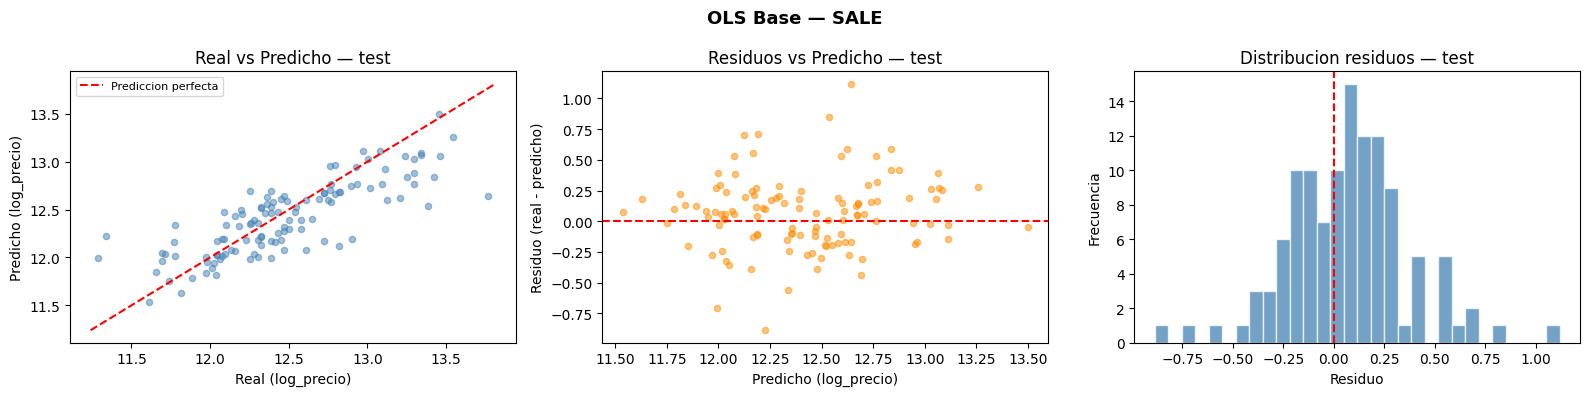


──────────────────────────────────────────────────────────────────────
MODELO 2: Ridge con RidgeCV (features Ridge + municipios)
──────────────────────────────────────────────────────────────────────

── Ingenieria de features ──────────────────────────────────────────
  Municipios agrupados en 'otros' (n=45): ['Ajo', 'Alfoz de Lloredo', 'Ampuero', 'Arcentales', 'Argoños', 'Arnuero', 'Barcena de Cicero', 'Beranga', 'Cartes', 'Castañeda', 'Colindres', 'Cudon', 'El Astillero', 'Entrambasaguas', 'Escalante', 'Galdames', 'Gallarta', 'Getxo', 'Guarnizo', 'Guriezo', 'Hazas de Cesto', 'Heras', 'Isla', 'Liendo', 'Limpias', 'Marina de Cudeyo', 'Medio Cudeyo', 'Meruelo', 'Miengo', 'Mogro', 'Muskiz', 'Penagos', 'Puente San Miguel', 'Ramales de la Victoria', 'Reocin', 'Ribamontan al Mar', 'Ribamontan al Monte', 'Santa Maria de Cayon', 'Santillana del Mar', 'Solares', 'Solorzano', 'Sopuerta', 'Vargas', 'Villapresente', 'Zierbena']
  Municipios mantenidos (n=14): ['Camargo', 'Castro-Urdiales', 'Lar

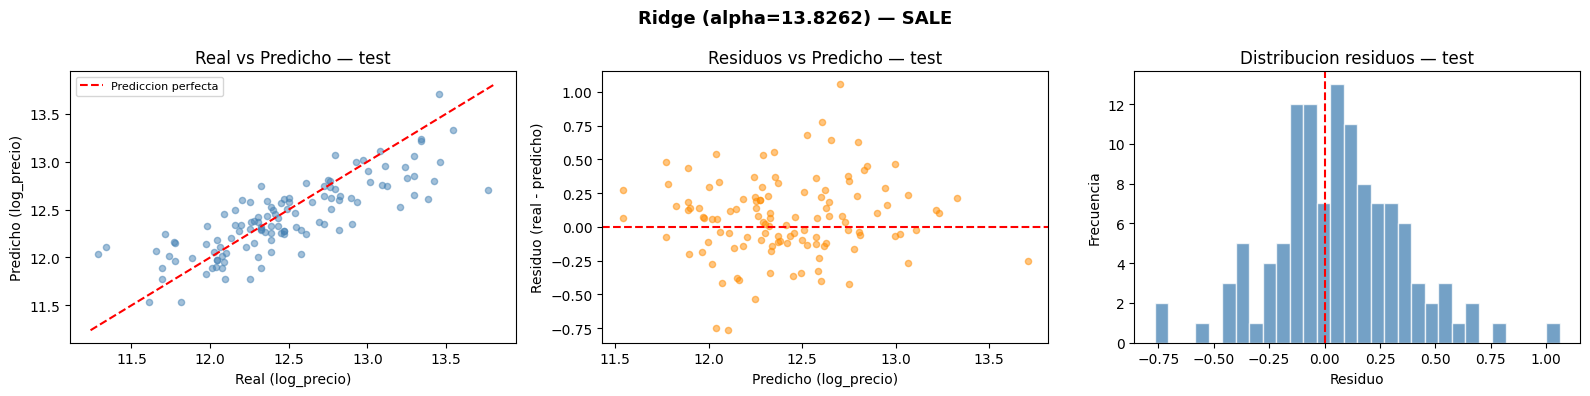


──────────────────────────────────────────────────────────────────────
MODELO 3: OLS + seleccion de variables con LassoCV
──────────────────────────────────────────────────────────────────────

── Ingenieria de features ──────────────────────────────────────────
  Municipios agrupados en 'otros' (n=45): ['Ajo', 'Alfoz de Lloredo', 'Ampuero', 'Arcentales', 'Argoños', 'Arnuero', 'Barcena de Cicero', 'Beranga', 'Cartes', 'Castañeda', 'Colindres', 'Cudon', 'El Astillero', 'Entrambasaguas', 'Escalante', 'Galdames', 'Gallarta', 'Getxo', 'Guarnizo', 'Guriezo', 'Hazas de Cesto', 'Heras', 'Isla', 'Liendo', 'Limpias', 'Marina de Cudeyo', 'Medio Cudeyo', 'Meruelo', 'Miengo', 'Mogro', 'Muskiz', 'Penagos', 'Puente San Miguel', 'Ramales de la Victoria', 'Reocin', 'Ribamontan al Mar', 'Ribamontan al Monte', 'Santa Maria de Cayon', 'Santillana del Mar', 'Solares', 'Solorzano', 'Sopuerta', 'Vargas', 'Villapresente', 'Zierbena']
  Municipios mantenidos (n=14): ['Camargo', 'Castro-Urdiales', 'Laredo', '

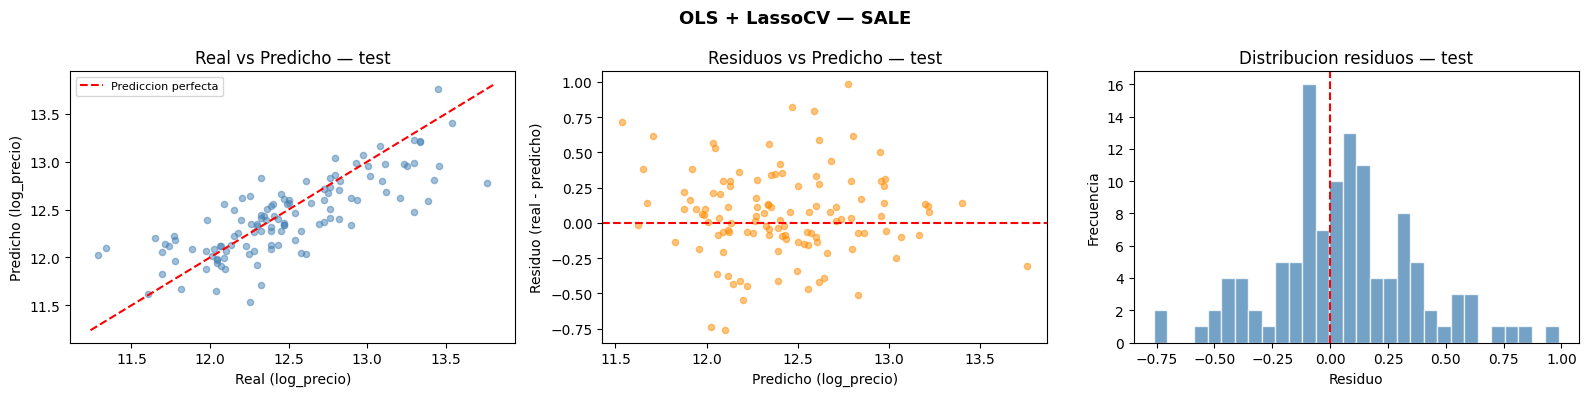


DATASET: RENT

Filas originales: 477
Detectando outliers en el target:
  Rango valido [log_precio]: [6.1079, 7.8074]
  Outliers eliminados: 26 / 477 (5.5%)
Filas tras limpieza: 451

──────────────────────────────────────────────────────────────────────
MODELO 1: OLS BASE (11 features parsimoniosas, sin regularizacion)
──────────────────────────────────────────────────────────────────────

Features (11): ['log_superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'distancia_centro_municipio_km', 'tipologia_unificada_unifamiliar', 'precio_m2_municipio_media']
Train: 360 | Test: 91

── Metricas ────────────────────────────────────────────────────────
      split     MSE    RMSE     MAE    MAPE      R2  R2_ajustado
      train 0.04092 0.20228 0.15526 0.02231 0.54897      0.53471
CV (5-fold) 0.04461 0.21054 0.16125 0.02317 0.52386      0.45686
       test 0.04671 

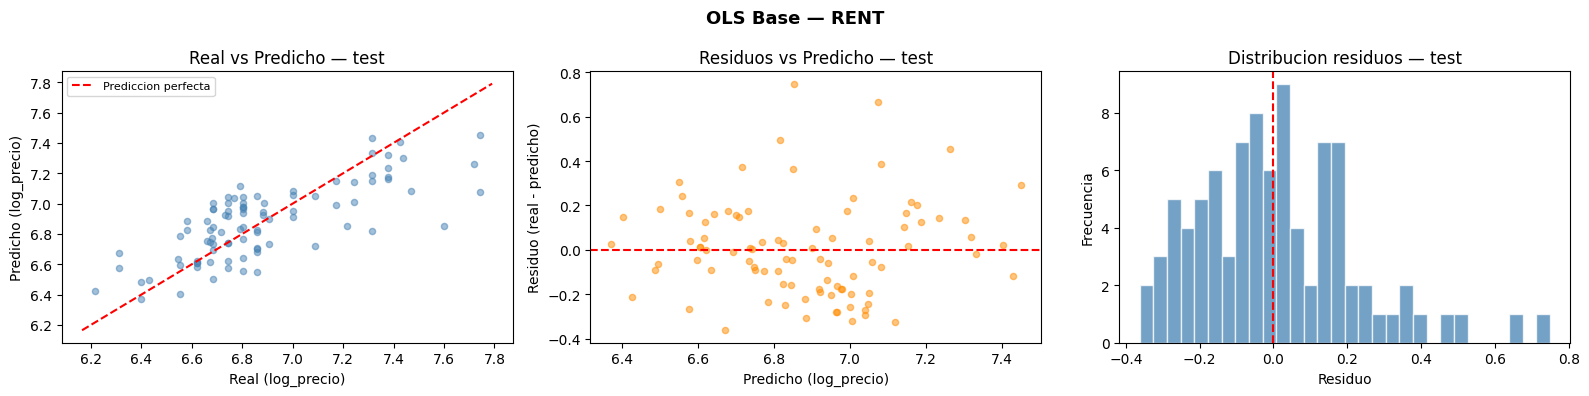


──────────────────────────────────────────────────────────────────────
MODELO 2: Ridge con RidgeCV (features Ridge + municipios)
──────────────────────────────────────────────────────────────────────

── Ingenieria de features ──────────────────────────────────────────
  Municipios agrupados en 'otros' (n=30): ['Ampuero', 'Barcena de Cicero', 'Cartes', 'Colindres', 'Cudon', 'Entrambasaguas', 'Gallarta', 'Getxo', 'Guarnizo', 'Guriezo', 'Liendo', 'Limpias', 'Marina de Cudeyo', 'Miengo', 'Noja', 'Polanco', 'Ramales de la Victoria', 'Reocin', 'Ribamontan al Mar', 'Santa Maria de Cayon', 'Santillana del Mar', 'Santoña', 'Santurtzi', 'Sobremazas', 'Solares', 'Suances', 'Villaescusa', 'Villapresente', 'Viveda', 'Voto']
  Municipios mantenidos (n=8): ['Camargo', 'Castro-Urdiales', 'El Astillero', 'Laredo', 'Piélagos', 'Santa Cruz de Bezana', 'Santander', 'Torrelavega']

Features candidatas (29): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'latitud', 'longitud', 'planta'

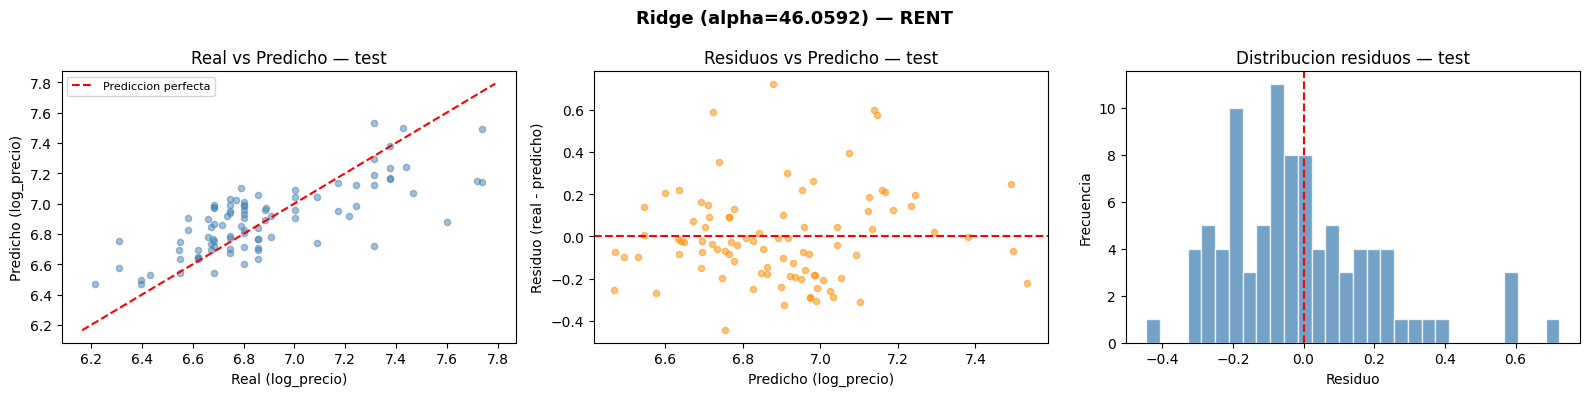


──────────────────────────────────────────────────────────────────────
MODELO 3: OLS + seleccion de variables con LassoCV
──────────────────────────────────────────────────────────────────────

── Ingenieria de features ──────────────────────────────────────────
  Municipios agrupados en 'otros' (n=30): ['Ampuero', 'Barcena de Cicero', 'Cartes', 'Colindres', 'Cudon', 'Entrambasaguas', 'Gallarta', 'Getxo', 'Guarnizo', 'Guriezo', 'Liendo', 'Limpias', 'Marina de Cudeyo', 'Miengo', 'Noja', 'Polanco', 'Ramales de la Victoria', 'Reocin', 'Ribamontan al Mar', 'Santa Maria de Cayon', 'Santillana del Mar', 'Santoña', 'Santurtzi', 'Sobremazas', 'Solares', 'Suances', 'Villaescusa', 'Villapresente', 'Viveda', 'Voto']
  Municipios mantenidos (n=8): ['Camargo', 'Castro-Urdiales', 'El Astillero', 'Laredo', 'Piélagos', 'Santa Cruz de Bezana', 'Santander', 'Torrelavega']

Features candidatas (37): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'latitud', 'longitud', 'planta', 'es_e

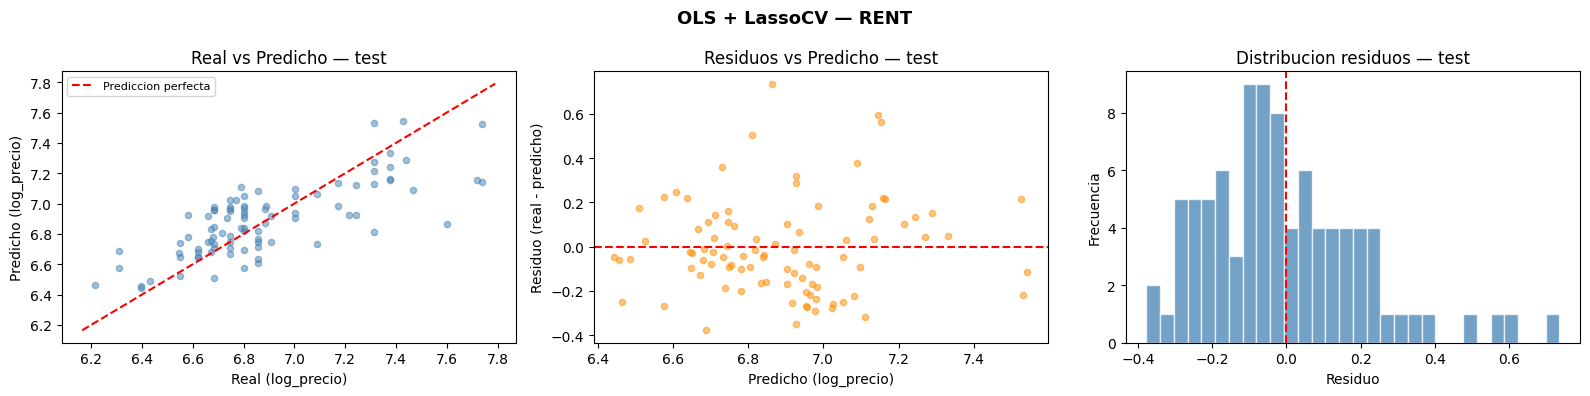

In [4]:
all_results = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 100)

    # ── Carga y limpieza ──────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"\nFilas originales: {len(df)}")
    print("Detectando outliers en el target:")
    df = remove_outliers_iqr(df)
    print(f"Filas tras limpieza: {len(df)}")

    y = df[TARGET_COL].copy()

    # ═══════════════════════════════════════════════════════════════════════════
    # MODELO 1 — OLS BASE (parsimonioso, 11 features)
    # ═══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 70)
    print("MODELO 1: OLS BASE (11 features parsimoniosas, sin regularizacion)")
    print("─" * 70)

    X_base = build_base_X(df)
    n_feat_b = X_base.shape[1]
    print(f"\nFeatures ({n_feat_b}): {X_base.columns.tolist()}")

    X_train_b, X_test_b, y_train, y_test = train_test_split(
        X_base, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train_b)} | Test: {len(X_test_b)}")

    ols_base     = fit_ols_statsmodels(X_train_b, y_train)
    X_train_bc   = sm.add_constant(X_train_b.astype(float))
    X_test_bc    = sm.add_constant(X_test_b.astype(float), has_constant="add")
    pred_train_b = ols_base.predict(X_train_bc)
    pred_test_b  = ols_base.predict(X_test_bc)

    train_m_b = compute_metrics(y_train, pred_train_b, n_feat_b)
    test_m_b  = compute_metrics(y_test,  pred_test_b,  n_feat_b)
    cv_m_b    = cv_ols_metrics(X_base, y, n_feat_b)

    print("\n── Metricas ────────────────────────────────────────────────────────")
    print(pd.DataFrame([
        {"split": "train",                **train_m_b},
        {"split": f"CV ({N_SPLITS}-fold)", **cv_m_b},
        {"split": "test",                 **test_m_b},
    ]).round(5).to_string(index=False))
    print(f"\n  delta RMSE test-train : {test_m_b['RMSE'] - train_m_b['RMSE']:+.5f}")
    print(f"  delta R2   train-test : {train_m_b['R2'] - test_m_b['R2']:+.5f}")
    print(f"  R2 ajustado (statsmodels): {ols_base.rsquared_adj:.5f}")
    print(f"  F-stat: {ols_base.fvalue:.2f}  p-value F: {ols_base.f_pvalue:.2e}")

    print("\n── Coeficientes OLS (ordenados por |coef|) ─────────────────────────")
    print_coef_summary(ols_base)

    plot_diagnostics(y_test, pred_test_b, f"OLS Base — {dataset_name.upper()}")

    all_results.append({
        "dataset":  dataset_name,
        "modelo":   "OLS_base",
        "n_features": n_feat_b,
        "alpha":    "—",
        "train_RMSE":      train_m_b["RMSE"],
        "train_R2":        train_m_b["R2"],
        "train_R2_adj":    train_m_b["R2_ajustado"],
        f"CV_{N_SPLITS}f_RMSE": cv_m_b["RMSE"],
        f"CV_{N_SPLITS}f_R2":   cv_m_b["R2"],
        "test_RMSE":  test_m_b["RMSE"],
        "test_R2":    test_m_b["R2"],
        "test_MAE":   test_m_b["MAE"],
        "test_MAPE":  test_m_b["MAPE"],
        "delta_RMSE": test_m_b["RMSE"] - train_m_b["RMSE"],
        "delta_R2":   train_m_b["R2"]  - test_m_b["R2"],
    })

    # ═══════════════════════════════════════════════════════════════════════════
    # MODELO 2 — RIDGE (RidgeCV, features Ridge)
    # ═══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 70)
    print("MODELO 2: Ridge con RidgeCV (features Ridge + municipios)")
    print("─" * 70)

    print("\n── Ingenieria de features ──────────────────────────────────────────")
    X_cand   = build_candidate_X(df, CANDIDATE_FEATURES_RIDGE)
    n_feat_r = X_cand.shape[1]
    print(f"\nFeatures candidatas ({n_feat_r}): {X_cand.columns.tolist()}")

    X_train_r, X_test_r, y_train, y_test = train_test_split(
        X_cand, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train_r)} | Test: {len(X_test_r)}")

    scaler_r   = StandardScaler()
    X_train_rs = scaler_r.fit_transform(X_train_r)
    X_test_rs  = scaler_r.transform(X_test_r)

    print("\n── RidgeCV (seleccion de alpha) ────────────────────────────────────")
    ridge_cv = RidgeCV(
        alphas=RIDGE_ALPHAS, cv=N_SPLITS, scoring="neg_mean_squared_error"
    )
    ridge_cv.fit(X_train_rs, y_train)
    alpha_ridge = ridge_cv.alpha_
    print(f"  Alpha optimo (CV): {alpha_ridge:.6f}")
    print(f"  Rango explorado: [{RIDGE_ALPHAS.min():.1e}, {RIDGE_ALPHAS.max():.1e}] ({len(RIDGE_ALPHAS)} valores)")

    ridge = Ridge(alpha=alpha_ridge)
    ridge.fit(X_train_rs, y_train)
    pred_train_r = ridge.predict(X_train_rs)
    pred_test_r  = ridge.predict(X_test_rs)

    train_m_r = compute_metrics(y_train, pred_train_r, n_feat_r)
    test_m_r  = compute_metrics(y_test,  pred_test_r,  n_feat_r)
    cv_m_r    = cv_ridge_metrics(X_cand, y, alpha_ridge, n_feat_r)

    print("\n── Metricas ────────────────────────────────────────────────────────")
    print(pd.DataFrame([
        {"split": "train",                **train_m_r},
        {"split": f"CV ({N_SPLITS}-fold)", **cv_m_r},
        {"split": "test",                 **test_m_r},
    ]).round(5).to_string(index=False))
    print(f"\n  delta RMSE test-train : {test_m_r['RMSE'] - train_m_r['RMSE']:+.5f}")
    print(f"  delta R2   train-test : {train_m_r['R2'] - test_m_r['R2']:+.5f}")

    print("\n── Coeficientes Ridge estandarizados (ordenados por |coef_std|) ────")
    coef_df_r = pd.DataFrame({
        "feature":   X_train_r.columns,
        "coef_std":  ridge.coef_,
        "coef_orig": ridge.coef_ / scaler_r.scale_,
    })
    coef_df_r["|coef_std|"] = coef_df_r["coef_std"].abs()
    coef_df_r = coef_df_r.sort_values("|coef_std|", ascending=False).drop(columns="|coef_std|")
    print(coef_df_r.round(5).to_string(index=False))
    print(f"\n  Intercepto (escala estandarizada): {ridge.intercept_:.5f}")

    plot_diagnostics(y_test, pred_test_r, f"Ridge (alpha={alpha_ridge:.4f}) — {dataset_name.upper()}")

    all_results.append({
        "dataset":  dataset_name,
        "modelo":   "Ridge",
        "n_features": n_feat_r,
        "alpha":    round(alpha_ridge, 6),
        "train_RMSE":      train_m_r["RMSE"],
        "train_R2":        train_m_r["R2"],
        "train_R2_adj":    train_m_r["R2_ajustado"],
        f"CV_{N_SPLITS}f_RMSE": cv_m_r["RMSE"],
        f"CV_{N_SPLITS}f_R2":   cv_m_r["R2"],
        "test_RMSE":  test_m_r["RMSE"],
        "test_R2":    test_m_r["R2"],
        "test_MAE":   test_m_r["MAE"],
        "test_MAPE":  test_m_r["MAPE"],
        "delta_RMSE": test_m_r["RMSE"] - train_m_r["RMSE"],
        "delta_R2":   train_m_r["R2"]  - test_m_r["R2"],
    })

    # ═══════════════════════════════════════════════════════════════════════════
    # MODELO 3 — LASSO + OLS (seleccion de variables con LassoCV, luego OLS)
    # ═══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 70)
    print("MODELO 3: OLS + seleccion de variables con LassoCV")
    print("─" * 70)

    print("\n── Ingenieria de features ──────────────────────────────────────────")
    X_lasso  = build_candidate_X(df, CANDIDATE_FEATURES_LASSO)
    n_feat_lc = X_lasso.shape[1]
    print(f"\nFeatures candidatas ({n_feat_lc}): {X_lasso.columns.tolist()}")

    X_train_l, X_test_l, y_train, y_test = train_test_split(
        X_lasso, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    print("\n── Seleccion con LassoCV ───────────────────────────────────────────")
    selected_features, alpha_lasso, lasso_coefs = select_features_lasso(X_train_l, y_train)
    print(f"  Alpha optimo (CV): {alpha_lasso:.6f}")
    eliminated = lasso_coefs[lasso_coefs == 0].index.tolist()
    print(f"  Features eliminadas por Lasso ({len(eliminated)}): {eliminated}")
    print(f"  Features seleccionadas ({len(selected_features)}): {selected_features}")

    nonzero_coefs = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)
    print("\n  Coeficientes Lasso estandarizados (no nulos, |coef| desc):")
    print(nonzero_coefs.round(5).to_string())

    if not selected_features:
        print("  Lasso elimino todas las features — se usaran todas.")
        selected_features = X_lasso.columns.tolist()

    X_train_ls = X_train_l[selected_features]
    X_test_ls  = X_test_l[selected_features]
    n_feat_l   = len(selected_features)

    print("\n── VIF (train, features seleccionadas) ─────────────────────────────")
    vif_df = compute_vif(X_train_ls)
    print(vif_df.round(3).to_string(index=False))
    alto_vif = vif_df[vif_df["VIF"] > 5]
    if not alto_vif.empty:
        print(f"\n  Variables con VIF > 5: {alto_vif['feature'].tolist()}")
    else:
        print("\n  Todos los VIF <= 5 — sin multicolinealidad problematica.")

    ols_lasso    = fit_ols_statsmodels(X_train_ls, y_train)
    X_train_lc   = sm.add_constant(X_train_ls.astype(float))
    X_test_lc    = sm.add_constant(X_test_ls.astype(float), has_constant="add")
    pred_train_l = ols_lasso.predict(X_train_lc)
    pred_test_l  = ols_lasso.predict(X_test_lc)

    train_m_l = compute_metrics(y_train, pred_train_l, n_feat_l)
    test_m_l  = compute_metrics(y_test,  pred_test_l,  n_feat_l)
    cv_m_l    = cv_ols_metrics(X_lasso[selected_features], y, n_feat_l)

    print("\n── Metricas ────────────────────────────────────────────────────────")
    print(pd.DataFrame([
        {"split": "train",                **train_m_l},
        {"split": f"CV ({N_SPLITS}-fold)", **cv_m_l},
        {"split": "test",                 **test_m_l},
    ]).round(5).to_string(index=False))
    print(f"\n  delta RMSE test-train : {test_m_l['RMSE'] - train_m_l['RMSE']:+.5f}")
    print(f"  delta R2   train-test : {train_m_l['R2'] - test_m_l['R2']:+.5f}")
    print(f"  R2 ajustado (statsmodels): {ols_lasso.rsquared_adj:.5f}")
    print(f"  F-stat: {ols_lasso.fvalue:.2f}  p-value F: {ols_lasso.f_pvalue:.2e}")

    print("\n── Coeficientes OLS tras Lasso (ordenados por |coef|) ──────────────")
    print_coef_summary(ols_lasso)

    plot_diagnostics(y_test, pred_test_l, f"OLS + LassoCV — {dataset_name.upper()}")

    all_results.append({
        "dataset":  dataset_name,
        "modelo":   "Lasso+OLS",
        "n_features": n_feat_l,
        "alpha":    round(alpha_lasso, 6),
        "train_RMSE":      train_m_l["RMSE"],
        "train_R2":        train_m_l["R2"],
        "train_R2_adj":    train_m_l["R2_ajustado"],
        f"CV_{N_SPLITS}f_RMSE": cv_m_l["RMSE"],
        f"CV_{N_SPLITS}f_R2":   cv_m_l["R2"],
        "test_RMSE":  test_m_l["RMSE"],
        "test_R2":    test_m_l["R2"],
        "test_MAE":   test_m_l["MAE"],
        "test_MAPE":  test_m_l["MAPE"],
        "delta_RMSE": test_m_l["RMSE"] - train_m_l["RMSE"],
        "delta_R2":   train_m_l["R2"]  - test_m_l["R2"],
    })

## Resumen comparativo global

In [5]:
print()
print("=" * 110)
print("RESUMEN GLOBAL — OLS BASE vs RIDGE vs LASSO+OLS")
print("=" * 110)

results_df = pd.DataFrame(all_results)

cols_show = [
    "dataset", "modelo", "n_features", "alpha",
    "train_RMSE", "train_R2", "train_R2_adj",
    f"CV_{N_SPLITS}f_RMSE", f"CV_{N_SPLITS}f_R2",
    "test_RMSE", "test_R2", "test_MAE", "test_MAPE",
    "delta_RMSE", "delta_R2",
]
cols_available = [c for c in cols_show if c in results_df.columns]
print(results_df[cols_available].round(5).to_string(index=False))
results_df[cols_available]


RESUMEN GLOBAL — OLS BASE vs RIDGE vs LASSO+OLS
dataset    modelo  n_features      alpha  train_RMSE  train_R2  train_R2_adj  CV_5f_RMSE  CV_5f_R2  test_RMSE  test_R2  test_MAE  test_MAPE  delta_RMSE  delta_R2
   sale  OLS_base          11          —     0.34176   0.61301       0.60361     0.34267   0.59274    0.30206  0.63262   0.22771    0.01816    -0.03970  -0.01962
   sale     Ridge          35  13.826222     0.31467   0.67191       0.64515     0.33154   0.61819    0.29968  0.63838   0.22913    0.01829    -0.01499   0.03354
   sale Lasso+OLS          26   0.007916     0.29857   0.70463       0.68710     0.37165   0.48283    0.31455  0.60162   0.23628    0.01890     0.01597   0.10301
   rent  OLS_base          11          —     0.20228   0.54897       0.53471     0.21054   0.52386    0.21613  0.56433   0.16674    0.02398     0.01385  -0.01536
   rent     Ridge          29   46.05922     0.19991   0.55946       0.52075     0.21253   0.51432    0.21695  0.56102   0.16608    0.02388  

,dataset,modelo,n_features,alpha,train_RMSE,train_R2,train_R2_adj,CV_5f_RMSE,CV_5f_R2,test_RMSE,test_R2,test_MAE,test_MAPE,delta_RMSE,delta_R2
0,sale,OLS_base,11,—,0.341756,0.613006,0.603609,0.342668,0.592739,0.302059,0.632624,0.227712,0.018162,-0.039697,-0.019618
1,sale,Ridge,35,13.826222,0.314672,0.671914,0.645147,0.331538,0.618191,0.299685,0.638378,0.229131,0.018291,-0.014988,0.033535
2,sale,Lasso+OLS,26,0.007916,0.298571,0.704630,0.687097,0.371653,0.482831,0.314546,0.601624,0.236281,0.018903,0.015975,0.103006
3,rent,OLS_base,11,—,0.202278,0.548970,0.534713,0.210543,0.523857,0.216132,0.564327,0.166742,0.023984,0.013854,-0.015357
4,rent,Ridge,29,46.05922,0.199911,0.559464,0.520750,0.212531,0.514319,0.216951,0.561021,0.166077,0.023881,0.017040,-0.001557
5,rent,Lasso+OLS,13,0.010692,0.201568,0.552130,0.535303,0.210396,0.523475,0.213344,0.575496,0.165101,0.023726,0.011776,-0.023366


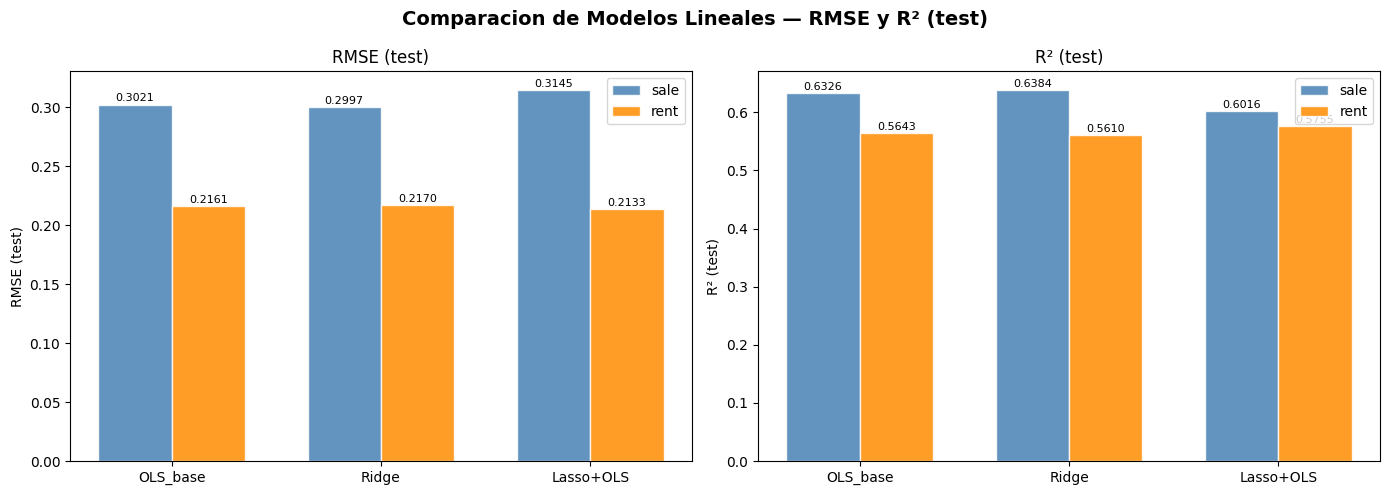

In [6]:
modelos      = ["OLS_base", "Ridge", "Lasso+OLS"]
datasets_lst = ["sale", "rent"]
colors       = {"sale": "steelblue", "rent": "darkorange"}
x            = np.arange(len(modelos))
width        = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Comparacion de Modelos Lineales — RMSE y R² (test)",
    fontsize=14, fontweight="bold"
)

for ax, metric, ylabel in zip(
    axes,
    ["test_RMSE", "test_R2"],
    ["RMSE (test)", "R² (test)"],
):
    for i, ds in enumerate(datasets_lst):
        subset = (
            results_df[results_df["dataset"] == ds]
            .set_index("modelo")
            .reindex(modelos)
        )
        offset = (i - 0.5) * width
        bars = ax.bar(
            x + offset, subset[metric], width,
            label=ds, color=colors[ds], alpha=0.85, edgecolor="white"
        )
        # Etiquetas encima de cada barra
        for bar, val in zip(bars, subset[metric]):
            if pd.notna(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.001 if metric == "test_RMSE" else 0.002),
                    f"{val:.4f}",
                    ha="center", va="bottom", fontsize=8
                )
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, fontsize=10)
    ax.set_title(ylabel, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()

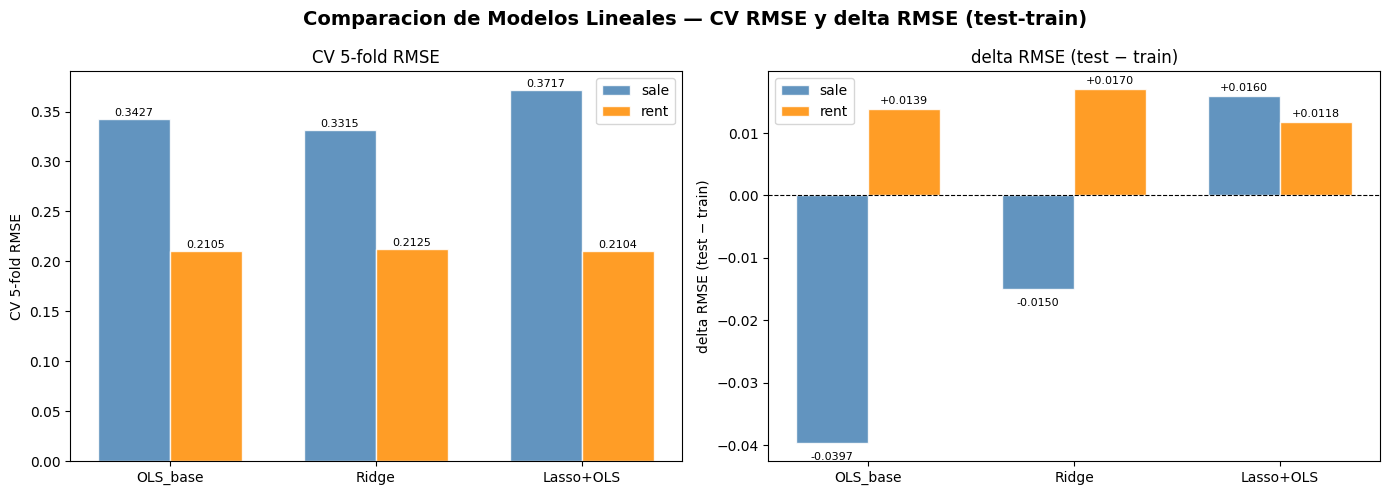

In [7]:
# Grafico adicional: CV RMSE y delta_RMSE (overfitting)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Comparacion de Modelos Lineales — CV RMSE y delta RMSE (test-train)",
    fontsize=14, fontweight="bold"
)

cv_rmse_col = f"CV_{N_SPLITS}f_RMSE"

for ax, metric, ylabel in zip(
    axes,
    [cv_rmse_col, "delta_RMSE"],
    [f"CV {N_SPLITS}-fold RMSE", "delta RMSE (test − train)"],
):
    for i, ds in enumerate(datasets_lst):
        subset = (
            results_df[results_df["dataset"] == ds]
            .set_index("modelo")
            .reindex(modelos)
        )
        offset = (i - 0.5) * width
        vals   = subset[metric]
        bar_colors = [colors[ds]] * len(vals)
        bars = ax.bar(
            x + offset, vals, width,
            label=ds, color=colors[ds], alpha=0.85, edgecolor="white"
        )
        for bar, val in zip(bars, vals):
            if pd.notna(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.0005 if val >= 0 else -0.003),
                    f"{val:+.4f}" if metric == "delta_RMSE" else f"{val:.4f}",
                    ha="center", va="bottom", fontsize=8
                )
    if metric == "delta_RMSE":
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, fontsize=10)
    ax.set_title(ylabel, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()